# Model Comparison - Train SVM Baseline
Notebook นี้ใช้ฝึก **SVM (RBF)** บนฟีเจอร์ 108 มิติจาก `transform_dataset` และบันทึกผลเพื่อใช้เปรียบเทียบใน Results.

In [1]:
import os
import sys
import json
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sys.path.insert(0, os.path.abspath('..'))
import src.config as config
from src.data.processing import transform_dataset, video_based_split

print('✓ Libraries loaded (with video_based_split)')

✓ Libraries loaded (with video_based_split)


In [2]:
data_dir = os.path.join(config.DATASET_DIR, 'by_class')
dfs = []

for file_name in sorted(os.listdir(data_dir)):
    if not file_name.endswith('.csv'):
        continue
    csv_path = os.path.join(data_dir, file_name)
    df_raw = pd.read_csv(csv_path).dropna()
    df_pro = transform_dataset(df_raw)
    if df_pro.empty:
        continue
    dfs.append(df_pro)
    print(f'Loaded {file_name}: {len(df_pro)} samples')

if not dfs:
    raise RuntimeError('No data loaded from dataset/by_class')

df = pd.concat(dfs, ignore_index=True)
X = df.drop(columns=['label']).values.astype(np.float32)
y = df['label'].astype(str).values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Use VIDEO-BASED SPLIT to prevent data leakage from sequential frames
# chunk_size=50 assumes ~50 consecutive frames per video segment
print('\n⚠️  Using VIDEO-BASED SPLIT (no data leakage)')
X_train, X_test, y_train, y_test = video_based_split(
    X, y_encoded, test_size=0.2, val_size=0, chunk_size=50, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Classes: {list(encoder.classes_)}')
print('✓ Honest train/test split completed')

Loaded block.csv: 500 samples


Loaded dodge_back.csv: 300 samples
Loaded dodge_front.csv: 300 samples


Loaded dodge_left.csv: 300 samples
Loaded dodge_right.csv: 300 samples


Loaded final_skill.csv: 300 samples


Loaded left_punch.csv: 300 samples


Loaded neutral.csv: 500 samples


Loaded right_punch.csv: 300 samples

⚠️  Using VIDEO-BASED SPLIT (no data leakage)
Train: (2500, 108), Test: (600, 108)
Classes: ['block', 'dodge_back', 'dodge_front', 'dodge_left', 'dodge_right', 'final_skill', 'left_punch', 'neutral', 'right_punch']
✓ Honest train/test split completed


In [3]:
param_grid = {
    'C': [1, 10, 50],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
model = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV score: {search.best_score_:.4f}')

Fitting 3 folds for each of 9 candidates, totalling 27 fits


Best params: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV score: 0.9680


Test Accuracy: 0.9500
Macro F1: 0.9438

Classification Report:
              precision    recall  f1-score   support

       block       1.00      1.00      1.00        50
  dodge_back       1.00      0.95      0.97       100
 dodge_front       0.97      1.00      0.99       100
  dodge_left       1.00      0.64      0.78        50
 dodge_right       1.00      1.00      1.00        50
 final_skill       1.00      1.00      1.00        50
  left_punch       0.98      1.00      0.99        50
     neutral       0.69      1.00      0.82        50
 right_punch       0.96      0.93      0.94       100

    accuracy                           0.95       600
   macro avg       0.96      0.95      0.94       600
weighted avg       0.96      0.95      0.95       600



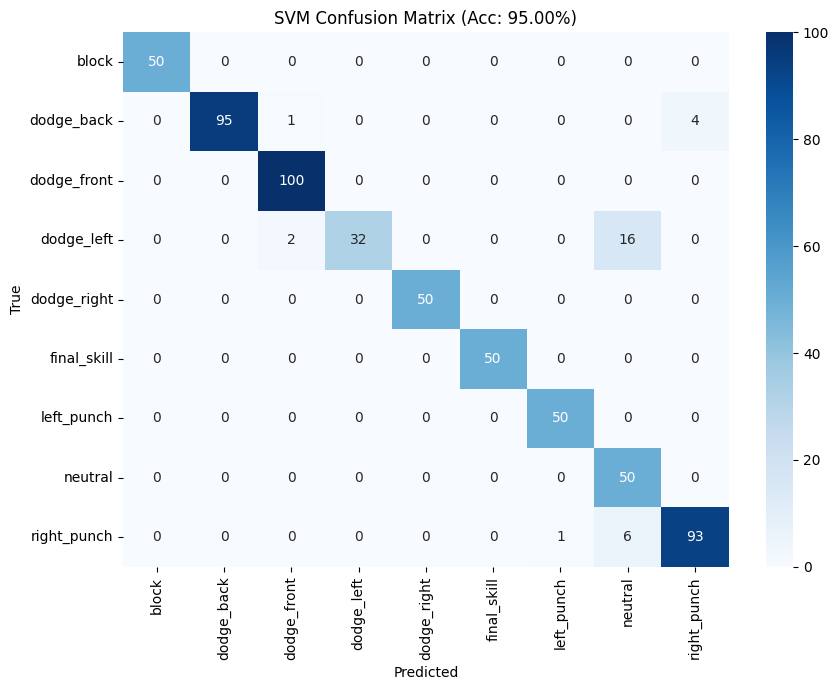

In [4]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f'Test Accuracy: {acc:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f'SVM Confusion Matrix (Acc: {acc*100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [5]:
sample = X_test[:1]
for _ in range(50):
    _ = model.predict(sample)

runs = 300
t0 = time.perf_counter()
for _ in range(runs):
    _ = model.predict(sample)
t1 = time.perf_counter()

latency_ms = (t1 - t0) / runs * 1000
print(f'Inference latency (1 sample): {latency_ms:.4f} ms')

Inference latency (1 sample): 0.2593 ms


In [6]:
from datetime import datetime

# Create timestamped folder for this run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_folder = f'svm_{timestamp}'

models_out = os.path.join(config.MODELS_DIR, 'model_comparison', 'svm', run_folder)
reports_out = os.path.join(config.PROJECT_ROOT, 'reports', 'model_comparison', 'svm', run_folder)
os.makedirs(models_out, exist_ok=True)
os.makedirs(reports_out, exist_ok=True)

print(f'Saving to run folder: {run_folder}')

# Save model artifacts
with open(os.path.join(models_out, 'svm_model.pkl'), 'wb') as f:
    pickle.dump(model, f)
with open(os.path.join(models_out, 'svm_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(models_out, 'svm_label_encoder.pkl'), 'wb') as f:
    pickle.dump(encoder, f)

# Save confusion matrix
cm_path = os.path.join(reports_out, 'confusion_matrix.png')
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f'SVM Confusion Matrix (Acc: {acc*100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(cm_path, dpi=160)
plt.close()

# Save metrics
metrics = {
    'model': 'SVM (RBF)',
    'timestamp': timestamp,
    'run_folder': run_folder,
    'accuracy': float(acc),
    'macro_f1': float(macro_f1),
    'inference_latency_ms': float(latency_ms),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'num_features': int(X_train.shape[1]),
    'classes': list(encoder.classes_),
    'best_params': search.best_params_
}

metrics_path = os.path.join(reports_out, 'metrics.json')
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

# Also save to root comparison folder for summary
root_metrics_path = os.path.join(config.PROJECT_ROOT, 'reports', 'model_comparison', 'svm_metrics.json')
with open(root_metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f'✓ Saved model to: {models_out}')
print(f'✓ Saved reports to: {reports_out}')
print(f'✓ Metrics: {metrics_path}')

Saving to run folder: svm_20260305_230033


✓ Saved model to: D:\ML-AI Motion Controller\models\model_comparison\svm\svm_20260305_230033
✓ Saved reports to: D:\ML-AI Motion Controller\reports\model_comparison\svm\svm_20260305_230033
✓ Metrics: D:\ML-AI Motion Controller\reports\model_comparison\svm\svm_20260305_230033\metrics.json
